In [1]:
# Import the necessary toolkits
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Unemployment in India.csv')

print("Data loaded successfully! Here are the first 3 rows:")
print(df.head(3))

Data loaded successfully! Here are the first 3 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  


In [2]:
# 1. Strip the extra spaces from the column names
df.columns = df.columns.str.strip()

# 2. Drop the rows that have missing data (NaN)
df = df.dropna()

# Let's check the info again to confirm it's clean
print("Clean Data Info:")
print(df.info())


Clean Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 46.2+ KB
None


In [3]:
# Get basic statistics (average, minimum, maximum) for the numbers
print("Basic Statistics:")
print(df.describe())

# Let's see how many records we have for each Region (State)
print("\nNumber of records per Region:")
print(df['Region'].value_counts())

Basic Statistics:
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                            

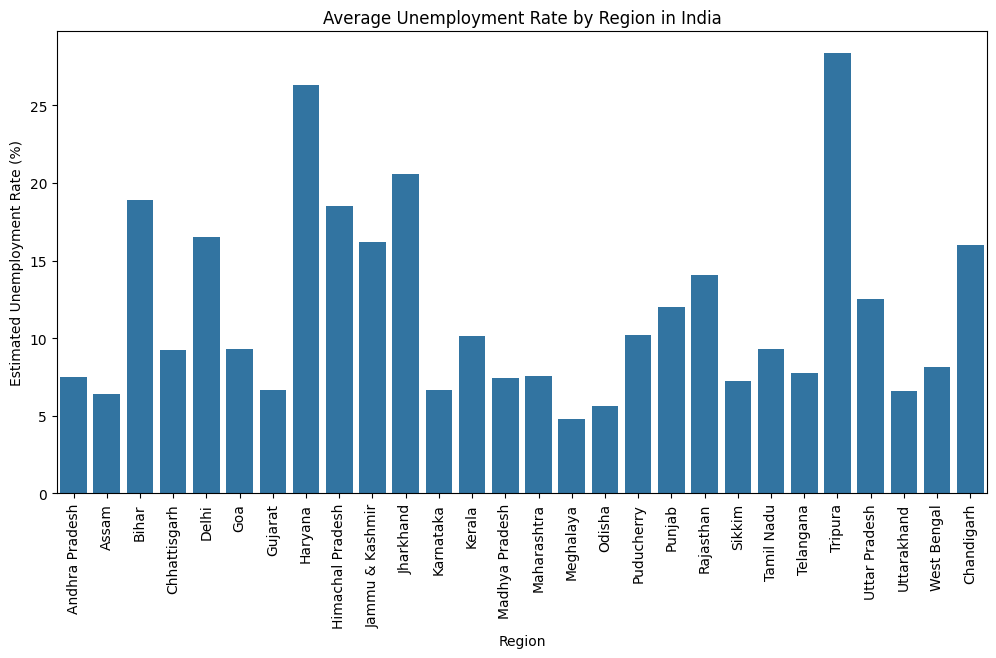

In [4]:
# Set the size of the graph
plt.figure(figsize=(12, 6))

# Create a bar chart showing Region vs Unemployment Rate
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df, errorbar=None)

# Rotate the x-axis labels so the state names don't overlap
plt.xticks(rotation=90)

# Add a title
plt.title('Average Unemployment Rate by Region in India')

# Show the graph!
plt.show()

In [5]:
# Load the second dataset
df_2020 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

# Clean the column names (remove extra spaces)
df_2020.columns = df_2020.columns.str.strip()

# Drop any missing rows
df_2020 = df_2020.dropna()

print("2020 Dataset loaded and cleaned! Here are the columns we have to play with:")
print(df_2020.columns.tolist())

2020 Dataset loaded and cleaned! Here are the columns we have to play with:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [6]:
# Convert the 'Date' column to actual datetime objects
df_2020['Date'] = pd.to_datetime(df_2020['Date'], format='mixed', dayfirst=True)

# Sort the data by date so our graphs flow left-to-right properly
df_2020 = df_2020.sort_values(by='Date')

print("Dates converted successfully!")

Dates converted successfully!


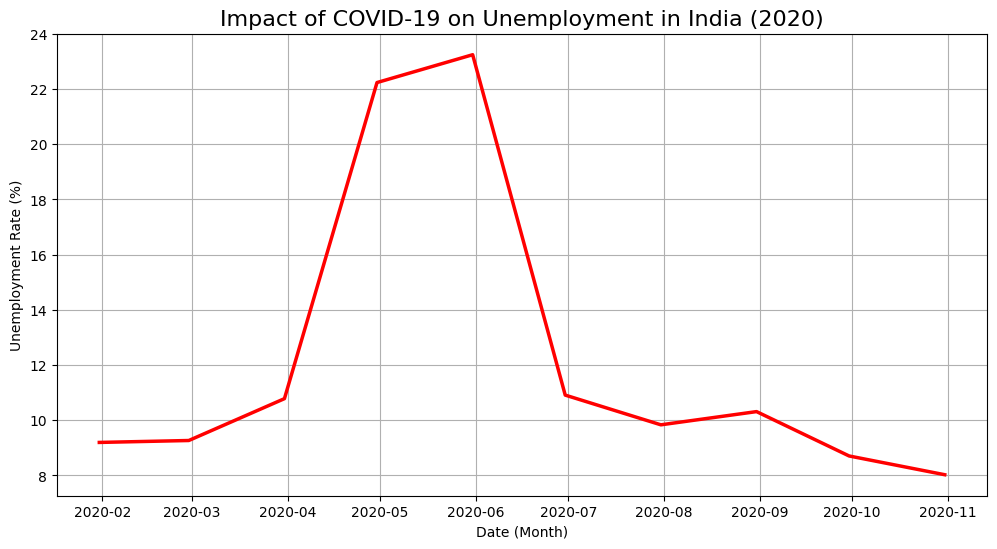

In [7]:
plt.figure(figsize=(12, 6))

# We use seaborn's lineplot to see the trend over time
# It will automatically calculate the average for each date!
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df_2020, errorbar=None, color='red', linewidth=2.5)

# Add titles and labels
plt.title('Impact of COVID-19 on Unemployment in India (2020)', fontsize=16)
plt.xlabel('Date (Month)')
plt.ylabel('Unemployment Rate (%)')

# Show the graph
plt.grid(True) # Adds a grid to make reading easier
plt.show()